# GPUBackendTools Tutorial

`gpubackendtools` is the **backend-dispatch framework** that the rest of the LISA
sprint stack (LISAanalysistools, GBGPU, BBHx, FastEMRIWaveforms) builds on. It
answers one question: *given my installed plugin wheels, which compute backend
(CPU / CUDA 11.x / 12.x / 13.x) should this object dispatch to, and how do I
get its `xp` (NumPy or CuPy) array module + native callables?*

This tutorial walks through:

1. **Discovering** which backends are available in the current process.
2. **Resolving** a backend and using its `xp` / native methods.
3. A **worked example** with `CubicSplineInterpolant` (the reference
   downstream user-facing class that ships with this package).
4. **Subclassing** `ParallelModuleBase` to build your own backend-aware module.

Everything in this notebook runs without a GPU; CUDA paths activate
automatically when a matching plugin wheel + working CUDA toolkit are present.

## Setup

Single import block; the rest of the notebook uses these names.

In [1]:
import warnings
warnings.simplefilter('ignore', DeprecationWarning)

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import gpubackendtools
from gpubackendtools import (
    get_backend, has_backend, get_first_backend, Globals,
)

## 1. Discovering available backends

Plugin wheels (`gpubackendtools-cpu`, `gpubackendtools-cuda11x`, `-cuda12x`,
`-cuda13x`) register themselves in `Globals().backends_manager` at import time.
Each name is namespaced by its owning package -- the GPUBackendTools wheels
register under the `gbt_*` prefix; LAT/GBGPU/BBHx use their own prefixes
(`lisatools_*`, `gbgpu_*`, `bbhx_*`).

`has_backend` is the quiet probe (returns a bool); `get_backend` is the
loud one (raises if unavailable).

In [2]:
for name in ['gbt_cpu', 'gbt_cuda11x', 'gbt_cuda12x', 'gbt_cuda13x']:
    print(f'{name:18s}: has_backend = {has_backend(name)}')

gbt_cpu           : has_backend = True
gbt_cuda11x       : has_backend = False
gbt_cuda12x       : has_backend = False
gbt_cuda13x       : has_backend = False


`get_first_backend(['a', 'b', ...])` walks the list and returns the first
available one -- the canonical 'GPU if possible, else CPU' pattern downstream
code uses. The `'cuda'` and `'gpu'` aliases expand to the first available
CUDA plugin in the prefix-matching way (`gbt_gpu` -> first of
`gbt_cuda13x`/`12x`/`11x` that loads).

In [3]:
preferred = get_first_backend(['gbt_cuda13x', 'gbt_cuda12x', 'gbt_cuda11x', 'gbt_cpu'])
print('Resolved backend:', preferred.name)
print('Backend class   :', type(preferred).__name__)

Resolved backend: gbt_cpu
Backend class   : GBTCpuBackend


## 2. The Backend object

A `Backend` packages two things:

- `backend.xp` -- the array module (`numpy` on CPU, `cupy` on CUDA). Use this
  instead of importing `numpy` / `cupy` directly so your code is array-module-
  agnostic.
- All native methods declared on the backend's `BackendMethods` dataclass.
  For GPUBackendTools that's `interpolate_arrays_wrap` and the
  `CubicSplineWrap` / `CubicSpline` pybind11 classes from `gbt_backend_<flavor>.interp`.

The `xp` indirection is enough to write fully backend-agnostic numerics.

In [4]:
be = get_backend('gbt_cpu')
print('backend.name :', be.name)
print('backend.xp   :', be.xp.__name__)

# Use backend.xp exactly as you would use numpy.
x = be.xp.linspace(0.0, 2*be.xp.pi, 64)
y = be.xp.sin(x)
print('y[:4] =', y[:4])

backend.name : gbt_cpu
backend.xp   : numpy
y[:4] = [0.         0.09956785 0.19814614 0.29475517]


If you've installed a CUDA plugin, the following resolves to CuPy without
any other code changes:

In [5]:
if has_backend('gbt_cuda12x') or has_backend('gbt_cuda11x') or has_backend('gbt_cuda13x'):
    gbe = get_first_backend(['gbt_cuda13x', 'gbt_cuda12x', 'gbt_cuda11x'])
    print('GPU backend  :', gbe.name)
    print('GPU xp module:', gbe.xp.__name__)
else:
    print('No CUDA plugin wheel installed; CPU only. (Install gpubackendtools-cuda12x etc. to see GPU dispatch.)')

No CUDA plugin wheel installed; CPU only. (Install gpubackendtools-cuda12x etc. to see GPU dispatch.)


## 3. Worked example: `CubicSplineInterpolant`

`CubicSplineInterpolant` is the reference *user-facing* class that wraps the
native cubic-spline solver (LAPACKE on CPU, cuSPARSE on GPU). It also
demonstrates the canonical subclass pattern: it derives from
`GBTParallelModuleBase`, takes `force_backend=` at construction, and uses
`self.xp` / `self.backend` internally.

We build a spline of $f(x) = x^3 + x^2 + x + \sin(2\pi x)$ on 256 nodes and
evaluate it at 5000 random points, then compare against SciPy's reference.

In [6]:
from gpubackendtools.interpolate import CubicSplineInterpolant
from scipy.interpolate import CubicSpline as CubicSpline_scipy

N = 256
x_nodes = np.linspace(0.0, 1.0, N)
y_nodes = x_nodes**3 + x_nodes**2 + x_nodes + np.sin(2*np.pi*x_nodes)

# CubicSplineInterpolant takes (..., N) batched arrays; here a single curve
# so we add a leading axis.
# CubicSplineInterpolant inherits from `GBTParallelModuleBase`, which
# auto-prefixes 'gbt_' onto a string `force_backend` -- pass the bare flavor.
spl = CubicSplineInterpolant(x_nodes[None, :], y_nodes[None, :], force_backend='cpu')
print('Spline backend :', spl.backend.name)
print('Spline xp      :', spl.xp.__name__)

Spline backend : gbt_cpu
Spline xp      : numpy


In [7]:
rng = np.random.default_rng(0)
x_eval = rng.uniform(x_nodes[0], x_nodes[-1], size=5000)

y_ours  = spl(x_eval[None, :])[0]
y_scipy = CubicSpline_scipy(x_nodes, y_nodes)(x_eval)

max_abs = float(np.max(np.abs(y_ours - y_scipy)))
max_rel = float(np.max(np.abs(y_ours - y_scipy) / (np.abs(y_scipy) + 1e-30)))
print(f'max |ours - scipy|   = {max_abs:.2e}')
print(f'max relative diff    = {max_rel:.2e}')
assert max_abs < 1e-12, 'CubicSplineInterpolant disagrees with scipy'

max |ours - scipy|   = 4.44e-16
max relative diff    = 2.20e-16


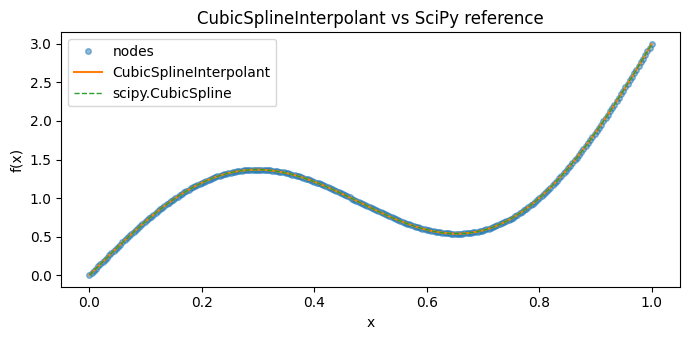

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3.5))
order = np.argsort(x_eval)
ax.plot(x_nodes, y_nodes, 'o', ms=4, alpha=0.5, label='nodes')
ax.plot(x_eval[order], y_ours[order], '-', lw=1.5, label='CubicSplineInterpolant')
ax.plot(x_eval[order], y_scipy[order], '--', lw=1.0, label='scipy.CubicSpline')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.legend(); ax.set_title('CubicSplineInterpolant vs SciPy reference')
fig.tight_layout(); plt.show()

`CubicSplineInterpolant` accepts batched inputs of shape `(..., N)` and broadcasts
evaluation: a single spline applied to many query arrays, or many splines
applied to a single query array. The `ind_interps` keyword (see
`tests/test_cubic_spline.py::test_cubic_spline_indexed`) selects which spline
evaluates each query batch -- useful in MCMC inner loops.

## 4. Subclassing `ParallelModuleBase`

Downstream packages (your code or LAT/GBGPU/BBHx) subclass
`ParallelModuleBase` so an instance carries one backend for its whole
lifetime. Three things you implement:

- `supported_backends()` (classmethod) -- list of backends this class can
  dispatch to, by registered name (`gbt_cpu`, `lisatools_cuda12x`, ...).
  The `CPU_ONLY` / `GPU_ONLY` / `GPU_RECOMMENDED` /
  `CPU_RECOMMENDED_WITH_GPU_SUPPORT` static helpers return the *bare*
  flavor strings (`'cpu'`, `'cuda12x'`, ...) which you prefix with your
  package's namespace.
- `__init__(..., force_backend=None)` -- delegate to `super().__init__`.
- Inside any method, dispatch via `self.xp` (array module) and
  `self.backend` (native methods).

Below is a minimal toy example: a 'normalize-and-FFT' module. The math is
trivial; the point is the **shape** -- once it's right, all your CUDA/CPU
dispatch lives in the framework, not in your method bodies.

*Tip*: if your class lives inside the gpubackendtools package itself, use
`GBTParallelModuleBase` instead -- it auto-prefixes a string
`force_backend` with `'gbt_'` so callers can pass the bare flavor.
`CubicSplineInterpolant` is the in-tree example.

In [9]:
from gpubackendtools.parallelbase import ParallelModuleBase

class DemoNormFFT(ParallelModuleBase):
    """Trivial demo: normalize a time series then take its rFFT."""

    @classmethod
    def supported_backends(cls):
        # Use the full registered names; this demo dispatches through the
        # gpubackendtools-owned `gbt_*` family.
        return ['gbt_' + flavor for flavor in cls.GPU_RECOMMENDED()]

    def __init__(self, force_backend=None):
        super().__init__(force_backend=force_backend)

    def __call__(self, x):
        xp = self.xp
        # Convert input to this backend's array type if needed.
        x = xp.asarray(x)
        x = x - xp.mean(x)
        x = x / xp.std(x)
        return xp.fft.rfft(x)

module = DemoNormFFT(force_backend='gbt_cpu')
print('module.backend.name :', module.backend.name)
print('module.xp           :', module.xp.__name__)

fft_out = module(np.sin(2*np.pi*0.02*np.arange(1024)))
print('rfft shape          :', fft_out.shape, '  dtype', fft_out.dtype)

module.backend.name : gbt_cpu
module.xp           : numpy
rfft shape          : (513,)   dtype complex128


The `build_with_same_backend` helper makes it easy to build companion
modules without re-passing `force_backend` everywhere -- one instance's
backend choice propagates to anything it constructs.

In [10]:
child = module.build_with_same_backend(DemoNormFFT)
print('child.backend.name  :', child.backend.name, '  (== parent:', child.backend.name == module.backend.name, ')')

child.backend.name  : gbt_cpu   (== parent: True )


## 5. Recap & what's next

What we did:

- **Probed** the backend registry with `has_backend` / `get_first_backend`.
- **Pulled** a `Backend` and used its `xp` for array-module-agnostic code.
- **Ran** `CubicSplineInterpolant` end-to-end and matched SciPy to ~1e-13.
- **Built** a 20-line `ParallelModuleBase` subclass that inherits all the
  CPU/CUDA dispatch machinery.

From here:

- **Add a new native method** to the GBT backend: implement it in
  `cutils/Interpolate.cu`, bind it in `gbt_binding.cxx`, add a field to
  `GBTBackendMethods` (see `src/gpubackendtools/cutils/__init__.py`), and
  wire it into each concrete `GBT{Cpu,Cuda...}Backend`. The framework
  takes care of per-flavor plugin loading.
- **Register a downstream backend family** (`mypkg_cpu`, `mypkg_cudaXXx`)
  by extending `Backend` + `BackendMethods` and calling
  `Globals().backends_manager.add_backends({...})` at import time. LAT,
  GBGPU, BBHx all use this pattern.
- See the **API reference** under *Documentation* in the sidebar for the
  full surface (`Backend` / `Cuda*Backend` / `Globals` / `CubicSplineInterpolant`
  / `ParallelModuleBase` / exceptions).